Slope: -0.23243243243243225, Intercept: 4.343243243243244


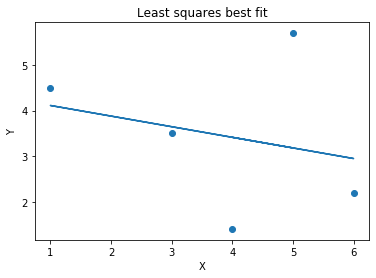

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Data points
X = np.array([4, 6, 3, 1, 5])
Y = np.array([1.4, 2.2, 3.5, 4.5, 5.7])

# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

print(f"Slope: {m}, Intercept: {c}")

# Plot data points
plt.scatter(X, Y)

# Plot best-fit line
y_fit = m*X + c
plt.plot(X, y_fit)

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least squares best fit")
plt.show()

Random test 
Slope: 0.05658948145527052, Intercept: 0.4488385800120381

True line used to generate data:
m_true = 1.6840296179047165, b_true = -0.11561517542746991

Least squares fit:
m_fit = 1.5901075873356452, b_fit = -0.0643160198046925

Residuals:
[-0.61653526 -0.81535879 -0.68413904  0.50509791  0.51166489 -0.35055315
 -0.07648167  0.39199278 -0.25837007  0.36568247] 

Point with largest residual:
index=41, X=0.41, Y=-0.3943, Y_pred=0.5876, residual=-0.9820

Point with smallest residual:
index=73, X=0.73, Y=1.0909, Y_pred=1.0965, residual=-0.0055



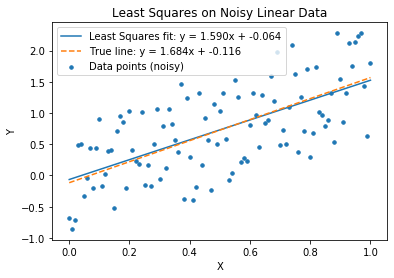

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42) 

X = rng.random(30)  
Y = rng.random(30) 
idx = np.argsort(X)
X = X[idx]
Y = Y[idx]

A = np.vstack([X, np.ones(len(X))]).T
m_rand, b_rand = np.linalg.lstsq(A, Y, rcond=None)[0]

print("Random test ")
print(f"Slope: {m_rand}, Intercept: {b_rand}\n")

#    y = mx + b +/- random_number(0,1)
m_true = rng.uniform(-5, 5)
b_true = rng.uniform(-2, 2)

X2 = np.arange(0, 1.0001, 0.01)

err = rng.random(len(X2))  
sign = rng.choice([-1, 1], size=len(X2))
Y2 = m_true * X2 + b_true + sign * err

print("True line used to generate data:")
print(f"m_true = {m_true}, b_true = {b_true}\n")

# run least squares on new data
A2 = np.vstack([X2, np.ones(len(X2))]).T
m_fit, b_fit = np.linalg.lstsq(A2, Y2, rcond=None)[0]

print("Least squares fit:")
print(f"m_fit = {m_fit}, b_fit = {b_fit}\n")

# residuals + largest/smallest residual points
Y_pred = m_fit * X2 + b_fit
residuals = Y2 - Y_pred

abs_res = np.abs(residuals)
i_max = np.argmax(abs_res)
i_min = np.argmin(abs_res)

print("Residuals:")
print(residuals[:10], "\n")

print("Point with largest residual:")
print(f"index={i_max}, X={X2[i_max]:.2f}, Y={Y2[i_max]:.4f}, Y_pred={Y_pred[i_max]:.4f}, residual={residuals[i_max]:.4f}\n")

print("Point with smallest residual:")
print(f"index={i_min}, X={X2[i_min]:.2f}, Y={Y2[i_min]:.4f}, Y_pred={Y_pred[i_min]:.4f}, residual={residuals[i_min]:.4f}\n")

plt.scatter(X2, Y2, s=12, label="Data points (noisy)")
plt.plot(X2, Y_pred, label=f"Least Squares fit: y = {m_fit:.3f}x + {b_fit:.3f}")
plt.plot(X2, m_true*X2 + b_true, linestyle="--", label=f"True line: y = {m_true:.3f}x + {b_true:.3f}")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares on Noisy Linear Data")
plt.legend()
plt.show()